# Pre-processing del dataset Breast Cancer Wisconsin: risultati

Questo notebook riassume i risultati del progetto:

1. **Esplorazione del dataset**: valori mancanti, target, colonna categorica e skewness.
2. **Le tre pipeline di pre-processing**, fittate sul training set e applicate al test set.
3. **Confronto tra strategie di imputazione**: `SimpleImputer`, `KNNImputer` e `IterativeImputer`.
4. **Analisi della PCA**: varianza spiegata e numero ottimale di componenti.

Le valutazioni dei punti 3 e 4 sono ripetute con due modelli molto diversi, una **regressione logistica** (lineare) e una **random forest** (ad alberi). Tutto il codice usato è nel pacchetto `src/preprocessing`.

> L'esecuzione completa richiede alcuni minuti, soprattutto per le cross-validation con la random forest.

In [1]:
import os
import re
import sys
import warnings
from pathlib import Path

# Avvisi attesi, silenziati anche nei processi paralleli della cross-validation:
# - IterativeImputer con random forest non raggiunge il criterio di arresto nelle 5 iterazioni previste
# - la discretizzazione della pipeline 2 unisce i bin coincidenti creati dai valori imputati
EXPECTED_WARNINGS = ["[IterativeImputer] Early stopping criterion not reached", "Bins whose width are too small"]
os.environ["PYTHONWARNINGS"] = ",".join(f"ignore:{message}" for message in EXPECTED_WARNINGS)
for message in EXPECTED_WARNINGS:
    warnings.filterwarnings("ignore", message=re.escape(message))

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

from preprocessing import (
    BENIGN,
    build_pipeline_1,
    build_pipeline_2,
    build_pipeline_3,
    categorical_columns,
    load_dataset,
    numerical_columns,
    split_by_skewness,
    split_features_target,
)
from preprocessing.analysis import (
    NO_PCA,
    SIMPLE,
    compare_imputers,
    components_for_variance,
    elbow_components,
    imputation_error,
    one_standard_error_components,
    pca_cv_scores,
    pca_explained_variance,
)

RANDOM_STATE = 42
pd.set_option("display.float_format", "{:.4f}".format)
plt.rcParams["figure.dpi"] = 100

## 1. Esplorazione del dataset

In [2]:
df = load_dataset()
print(f"Righe: {len(df)}, colonne: {len(df.columns)}")
df.head()

Righe: 569, colonne: 31


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,NaN,10.3800,122.8000,1001.0000,0.1184,0.2776,0.3001,0.1471,0.2419,0.0787,...,17.3300,NaN,2019.0000,0.1622,0.6656,0.7119,0.2654,0.4601,0.1189,0
1,20.5700,17.7700,132.9000,1326.0000,NaN,NaN,0.0869,0.0702,NaN,0.0567,...,23.4100,158.8000,1956.0000,0.1238,0.1866,0.2416,0.1860,0.2750,NaN,0
2,19.6900,21.2500,130.0000,1203.0000,0.1096,0.1599,NaN,NaN,NaN,0.0600,...,25.5300,NaN,1709.0000,0.1444,0.4245,0.4504,0.2430,0.3613,0.0876,0
3,11.4200,20.3800,77.5800,386.1000,0.1425,0.2839,0.2414,NaN,0.2597,0.0974,...,26.5000,NaN,567.7000,0.2098,0.8663,0.6869,0.2575,0.6638,0.1730,0
4,20.2900,14.3400,NaN,NaN,NaN,0.1328,0.1980,NaN,0.1809,NaN,...,16.6700,152.2000,1575.0000,0.1374,NaN,0.4000,0.1625,0.2364,0.0768,0


Tutte le feature contengono valori mancanti, in una percentuale tra il 10% e il 33% circa:

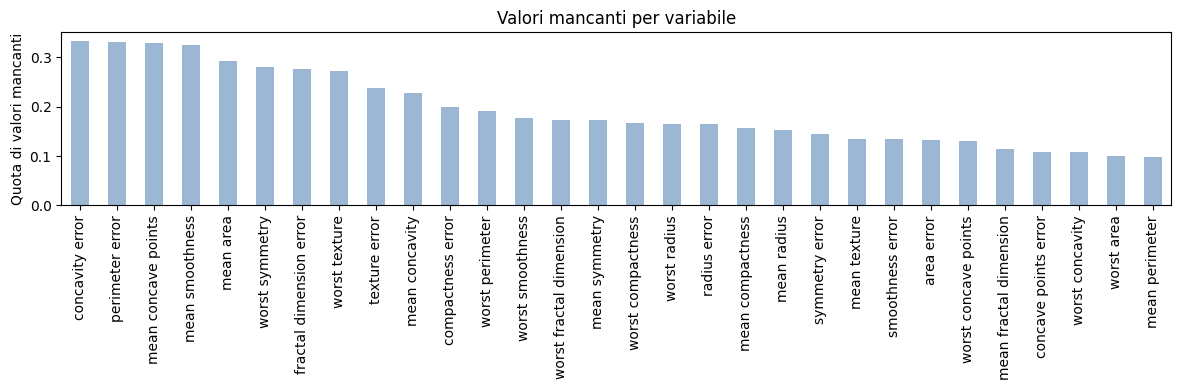

In [3]:
missing = df.isna().mean().sort_values(ascending=False).drop("target")
ax = missing.plot.bar(figsize=(12, 4), color="#9bb7d4")
ax.set_ylabel("Quota di valori mancanti")
ax.set_title("Valori mancanti per variabile")
plt.tight_layout()
plt.show()

Il target vale **0 = maligno** e **1 = benigno** (codifica di scikit-learn per questo dataset). La colonna `area error`, numerica nel dataset originale, qui contiene invece **categorie** (A, B, C):

In [4]:
X, y = split_features_target(df)
display(y.value_counts().rename(index={0: "0 (maligno)", 1: "1 (benigno)"}).to_frame("record"))
display(X["area error"].value_counts(dropna=False).to_frame("record"))

,record
target,
1 (benigno),357
0 (maligno),212


,record
area error,
A,489
NaN,75
B,4
C,1


### Skewness e divisione tra variabili simmetriche e asimmetriche

La divisione non è scritta a mano ma calcolata sul **training set**: una variabile è asimmetrica se il valore assoluto della skewness supera 0.5. Il test set viene tenuto da parte fin da subito, così nessuna scelta del pre-processing dipende da esso.

Training set: 455 record, test set: 114 record
Simmetriche (2): ['mean smoothness', 'worst smoothness']
Asimmetriche (27): 27 variabili
Categoriche: ['area error']


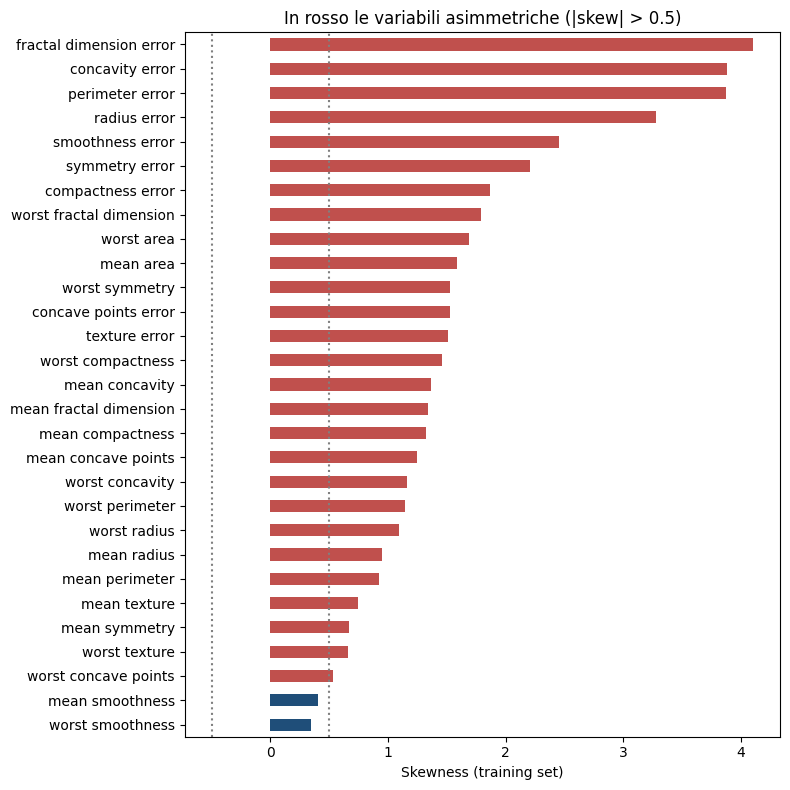

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)
categorical = categorical_columns(X_train)
symmetric, asymmetric = split_by_skewness(X_train)
print(f"Training set: {len(X_train)} record, test set: {len(X_test)} record")
print(f"Simmetriche ({len(symmetric)}): {symmetric}")
print(f"Asimmetriche ({len(asymmetric)}): {len(asymmetric)} variabili")
print(f"Categoriche: {categorical}")

skew = X_train[numerical_columns(X_train)].skew().sort_values()
ax = skew.plot.barh(figsize=(8, 8), color=np.where(skew.abs() > 0.5, "#c0504d", "#1f4e79"))
ax.axvline(0.5, color="grey", linestyle=":")
ax.axvline(-0.5, color="grey", linestyle=":")
ax.set_xlabel("Skewness (training set)")
ax.set_title("In rosso le variabili asimmetriche (|skew| > 0.5)")
plt.tight_layout()
plt.show()

Gli istogrammi di alcune variabili mostrano la differenza tra le due simmetriche (`mean smoothness`, `worst smoothness`) e alcune fortemente asimmetriche:

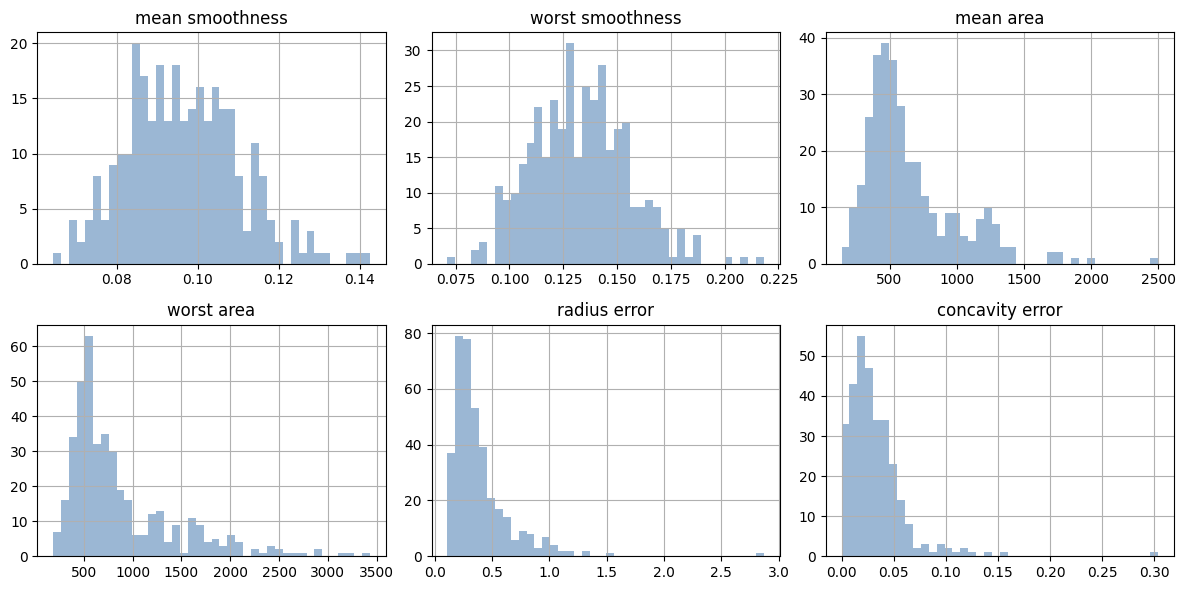

In [6]:
examples = ["mean smoothness", "worst smoothness", "mean area", "worst area", "radius error", "concavity error"]
X_train[examples].hist(bins=40, figsize=(12, 6), layout=(2, 3), color="#9bb7d4")
plt.tight_layout()
plt.show()

## 2. Le tre pipeline di pre-processing

Ogni pipeline viene fittata **solo sul training set** e poi applicata al test set con `transform`.

### Pipeline 1: solo i record con target = 1 (casi benigni)
Imputazione (media per le simmetriche, mediana per le asimmetriche, valore più frequente per le categoriche), simmetrizzazione Yeo-Johnson delle asimmetriche, one-hot encoding e standardizzazione.

In [7]:
pipeline1 = build_pipeline_1(symmetric, asymmetric, categorical)
pipeline1.fit(X_train[y_train == BENIGN])
X_test_1 = pd.DataFrame(
    pipeline1.transform(X_test[y_test == BENIGN]),
    columns=pipeline1.get_feature_names_out(),
)
print(f"Forma: {X_test_1.shape}")
X_test_1.describe().T[["mean", "std", "min", "max"]].head(10)

Forma: (72, 30)


,mean,std,min,max
numeriche simmetriche__mean smoothness,0.3453,1.5305,-3.9143,7.1141
numeriche simmetriche__worst smoothness,-0.0098,1.0912,-2.0684,3.5973
numeriche asimmetriche__mean radius,0.1131,1.0705,-2.5069,2.7650
numeriche asimmetriche__mean texture,0.0463,0.9359,-2.0586,2.1526
numeriche asimmetriche__mean perimeter,0.1947,1.0854,-2.6133,2.6836
numeriche asimmetriche__mean area,0.0912,1.0647,-2.7669,3.1524
numeriche asimmetriche__mean compactness,0.2072,1.1052,-2.1952,2.8510
numeriche asimmetriche__mean concavity,0.1565,0.8646,-2.1359,2.2200
numeriche asimmetriche__mean concave points,0.2064,1.1504,-2.8770,3.0554
numeriche asimmetriche__mean symmetry,0.2116,0.8941,-1.8139,2.9111


Nel sottoinsieme dei casi benigni `area error` contiene solo la categoria `A`, quindi il one-hot encoding produce una sola colonna. Le categorie mai viste nel fit vengono ignorate (`handle_unknown="ignore"`).

L'effetto della simmetrizzazione su una variabile asimmetrica:

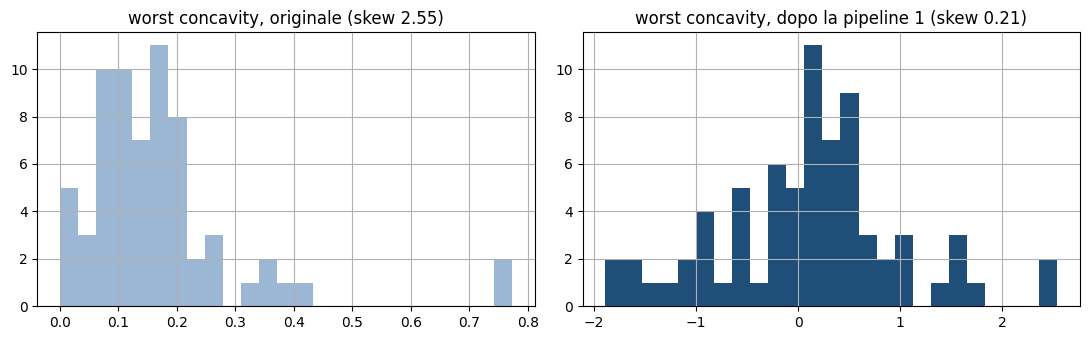

In [8]:
# Variabile asimmetrica con la skewness più alta tra i casi benigni del test set
original = X_test.loc[y_test == BENIGN, asymmetric]
column = original.skew().abs().idxmax()
transformed = X_test_1[f"numeriche asimmetriche__{column}"]

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
original[column].hist(bins=25, ax=axes[0], color="#9bb7d4")
axes[0].set_title(f"{column}, originale (skew {original[column].skew():.2f})")
transformed.hist(bins=25, ax=axes[1], color="#1f4e79")
axes[1].set_title(f"{column}, dopo la pipeline 1 (skew {transformed.skew():.2f})")
plt.tight_layout()
plt.show()

La trasformazione Yeo-Johnson riporta la distribuzione vicino alla simmetria. A destra compaiono anche i valori mancanti, imputati tutti con la mediana: per questo il picco centrale è più alto.

### Pipeline 2: tutti i record, discretizzazione e selezione delle 5 variabili migliori
Imputazione, discretizzazione in 20 bin per quantili, encoding ordinale (A < B < C) e selezione delle 5 variabili più informative con il test F per la classificazione (`f_classif`).

Forma: (114, 5)


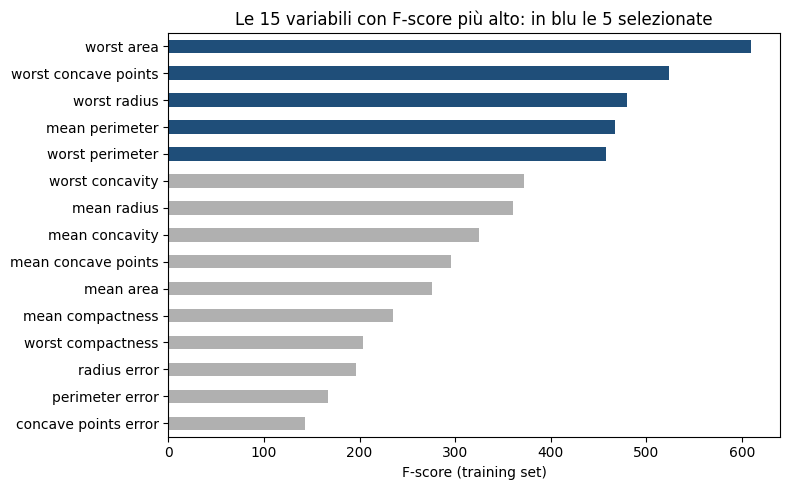

In [9]:
pipeline2 = build_pipeline_2(symmetric, asymmetric, categorical)
pipeline2.fit(X_train, y_train)
X_test_2 = pd.DataFrame(pipeline2.transform(X_test), columns=pipeline2.get_feature_names_out())
print(f"Forma: {X_test_2.shape}")

selector = pipeline2.named_steps["F-Score"]
names = pipeline2.named_steps["column_transformer"].get_feature_names_out()
f_scores = pd.Series(selector.scores_, index=[n.split("__")[1] for n in names]).sort_values(ascending=False)
ax = f_scores.head(15).iloc[::-1].plot.barh(
    figsize=(8, 5), color=["#b0b0b0"] * 10 + ["#1f4e79"] * 5
)
ax.set_xlabel("F-score (training set)")
ax.set_title("Le 15 variabili con F-score più alto: in blu le 5 selezionate")
plt.tight_layout()
plt.show()

### Pipeline 3: solo variabili numeriche, PCA e normalizzazione
Imputazione, simmetrizzazione e standardizzazione, PCA con l'80% della varianza spiegata e normalizzazione tra 0 e 1. Scalare le variabili **prima** della PCA è indispensabile: altrimenti le colonne con valori grandi (es. `mean area`, dell'ordine di 1000) dominano la varianza e la PCA si riduce a 2 componenti.

Forma: (114, 8)
Componenti: 8, varianza spiegata: 81.8%


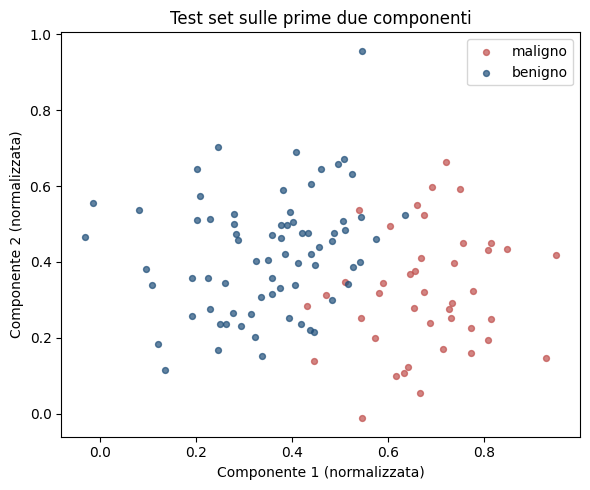

In [10]:
pipeline3 = build_pipeline_3(symmetric, asymmetric)
pipeline3.fit(X_train)
X_test_3 = pipeline3.transform(X_test)
pca = pipeline3.named_steps["PCA"]
print(f"Forma: {X_test_3.shape}")
print(f"Componenti: {pca.n_components_}, varianza spiegata: {pca.explained_variance_ratio_.sum():.1%}")

fig, ax = plt.subplots(figsize=(6, 5))
for label, name, color in [(0, "maligno", "#c0504d"), (1, "benigno", "#1f4e79")]:
    mask = (y_test == label).to_numpy()
    ax.scatter(X_test_3[mask, 0], X_test_3[mask, 1], s=18, alpha=0.7, color=color, label=name)
ax.set_xlabel("Componente 1 (normalizzata)")
ax.set_ylabel("Componente 2 (normalizzata)")
ax.set_title("Test set sulle prime due componenti")
ax.legend()
plt.tight_layout()
plt.show()

Già le prime due componenti separano bene i casi maligni da quelli benigni.

## 3. Confronto tra strategie di imputazione

Ogni pipeline accetta il parametro `numeric_imputer`. Oltre al `SimpleImputer` (default) sono stati provati:
- `KNNImputer`: usa la media dei k record più simili, dopo aver standardizzato le variabili;
- `IterativeImputer`: stima ogni variabile con una regressione sulle altre, con `BayesianRidge` (lineare) o con una random forest.

### Ricostruzione dei valori
Il 10% dei valori noti del training set viene nascosto e poi imputato. L'errore è misurato in deviazioni standard: 1.0 equivale a sbagliare di una deviazione standard.

,RMSE,MAE
imputer,,
IterativeImputer (BayesianRidge),0.5367,0.2745
IterativeImputer (random forest),0.6105,0.3223
KNNImputer (k=10),0.7135,0.4095
"KNNImputer (k=5, pesato)",0.7187,0.4064
KNNImputer (k=5),0.7217,0.4085
KNNImputer (k=3),0.7373,0.4220
SimpleImputer (media/mediana),1.1268,0.7613


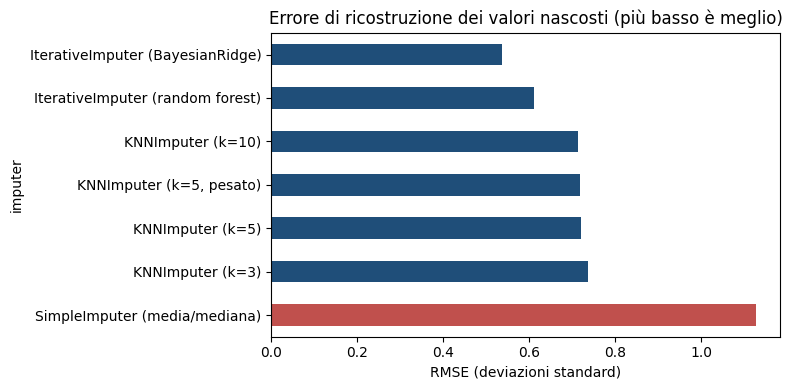

In [11]:
errors = imputation_error(X_train, symmetric, asymmetric, random_state=RANDOM_STATE)
display(errors)

ax = errors["RMSE"].iloc[::-1].plot.barh(
    figsize=(8, 4), color=["#c0504d" if name == SIMPLE else "#1f4e79" for name in errors.index[::-1]]
)
ax.set_xlabel("RMSE (deviazioni standard)")
ax.set_title("Errore di ricostruzione dei valori nascosti (più basso è meglio)")
plt.tight_layout()
plt.show()

L'`IterativeImputer` con `BayesianRidge` è il più preciso: le variabili sono legate da relazioni quasi lineari (es. raggio, perimetro e area), che una regressione cattura bene.

### Effetto sui modelli
Ogni combinazione di imputer e modello è valutata con una cross-validation a 5 fold sul training set, usando il pre-processing della pipeline 1.

In [12]:
scores = compare_imputers(X_train, y_train, symmetric, asymmetric, categorical, random_state=RANDOM_STATE)
summary = scores["ROC AUC"].unstack("modello")
summary = summary.loc[errors.index]
summary.insert(0, "RMSE ricostruzione", errors["RMSE"])
summary

modello,RMSE ricostruzione,Random forest,Regressione logistica
imputer,,,
IterativeImputer (BayesianRidge),0.5367,0.9909,0.9938
IterativeImputer (random forest),0.6105,0.9893,0.9938
KNNImputer (k=10),0.7135,0.9913,0.9949
"KNNImputer (k=5, pesato)",0.7187,0.9907,0.9950
KNNImputer (k=5),0.7217,0.9899,0.9949
KNNImputer (k=3),0.7373,0.9896,0.9947
SimpleImputer (media/mediana),1.1268,0.9902,0.9951


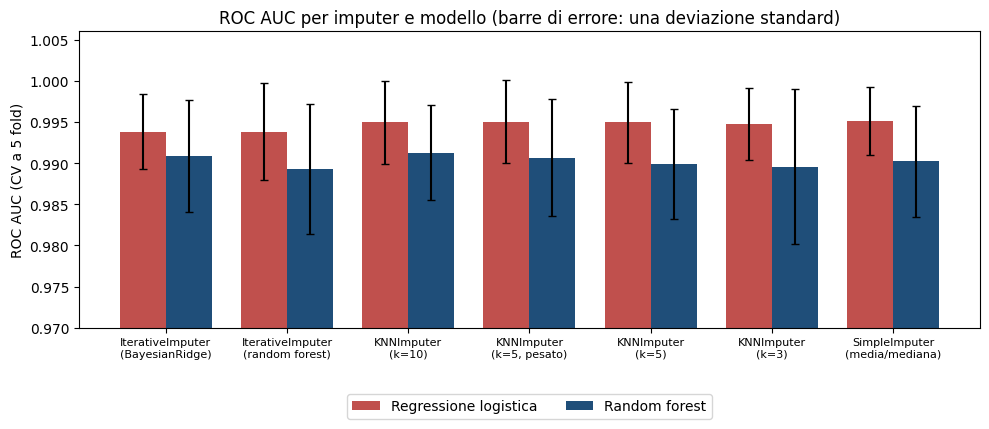

In [13]:
fig, ax = plt.subplots(figsize=(10, 4.5))
width = 0.38
positions = np.arange(len(errors.index))
for offset, (model, color) in zip([-width / 2, width / 2],
                                   [("Regressione logistica", "#c0504d"), ("Random forest", "#1f4e79")]):
    model_scores = scores.loc[model].loc[errors.index]
    ax.bar(positions + offset, model_scores["ROC AUC"], width, yerr=model_scores["ROC AUC std"],
           capsize=3, color=color, label=model)
ax.set_xticks(positions)
ax.set_xticklabels([name.replace(" (", "\n(") for name in errors.index], fontsize=8)
ax.set_ylim(0.97, 1.006)
ax.set_ylabel("ROC AUC (CV a 5 fold)")
ax.set_title("ROC AUC per imputer e modello (barre di errore: una deviazione standard)")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.2), ncol=2)
plt.tight_layout()
plt.show()

**Conclusioni sull'imputazione**
- Gli imputer multivariati ricostruiscono i valori molto meglio del `SimpleImputer`.
- Sulla classificazione però le differenze sono trascurabili **con entrambi i modelli**: tutte le strategie sono entro una deviazione standard l'una dall'altra.
- Le pipeline mantengono quindi il `SimpleImputer`, più semplice e veloce. L'`IterativeImputer` è la scelta migliore quando servono valori imputati realistici.
- La regressione logistica supera la random forest: dopo la simmetrizzazione le due classi sono separabili quasi linearmente.

## 4. Analisi della PCA

### Varianza spiegata

,componenti necessarie
varianza spiegata,
80%,8
90%,14
95%,20
99%,26


Gomito della curva cumulata: 7 componenti


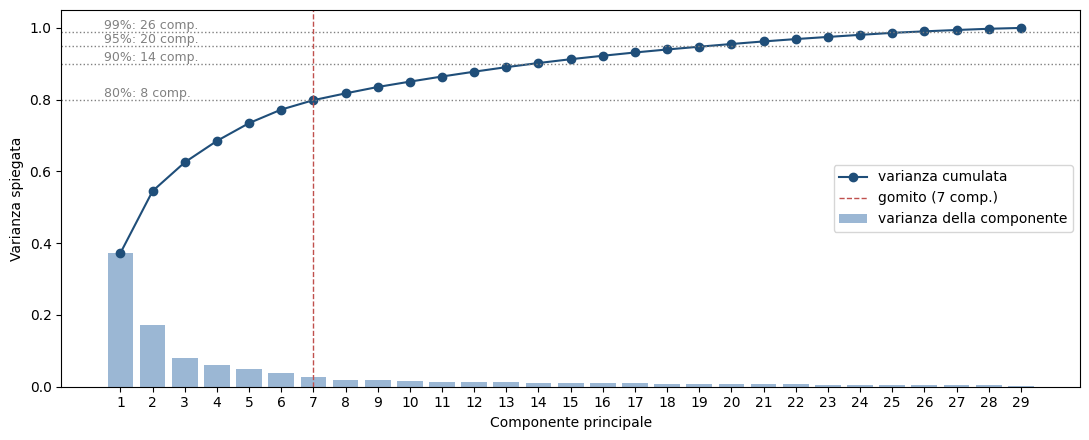

In [14]:
variance = pca_explained_variance(X_train, symmetric, asymmetric)
thresholds = components_for_variance(variance, (0.8, 0.9, 0.95, 0.99))
elbow = elbow_components(variance)
display(pd.Series(thresholds, name="componenti necessarie").rename_axis("varianza spiegata")
        .rename(index=lambda t: f"{t:.0%}").to_frame())
print(f"Gomito della curva cumulata: {elbow} componenti")

fig, ax = plt.subplots(figsize=(11, 4.5))
x = variance.index
ax.bar(x, variance["varianza spiegata"], color="#9bb7d4", label="varianza della componente")
ax.plot(x, variance["varianza cumulata"], marker="o", color="#1f4e79", label="varianza cumulata")
for t, n in thresholds.items():
    ax.axhline(t, color="grey", linestyle=":", linewidth=1)
    ax.annotate(f"{t:.0%}: {n} comp.", (0.5, t), textcoords="offset points", xytext=(0, 2), fontsize=9, color="grey")
ax.axvline(elbow, color="#c0504d", linestyle="--", linewidth=1, label=f"gomito ({elbow} comp.)")
ax.set_xlabel("Componente principale")
ax.set_ylabel("Varianza spiegata")
ax.set_xticks(list(x))
ax.set_ylim(0, 1.05)
ax.legend(loc="center right")
plt.tight_layout()
plt.show()

### Prestazioni al variare del numero di componenti
Entrambi i modelli vengono valutati con la pipeline 3 e un numero crescente di componenti, e confrontati con gli stessi modelli senza PCA (linee tratteggiate).

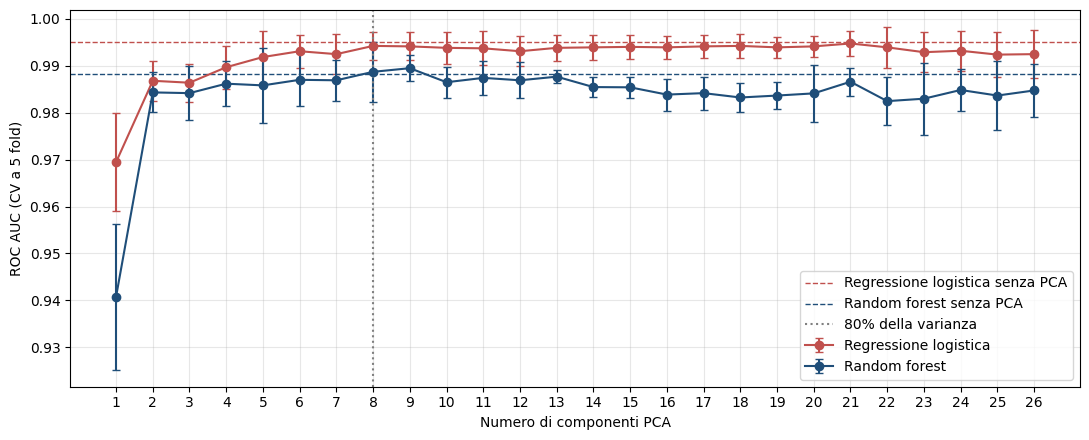

In [15]:
components = list(range(1, thresholds[0.99] + 1))
cv_scores = pca_cv_scores(X_train, y_train, symmetric, asymmetric, components, random_state=RANDOM_STATE)

fig, ax = plt.subplots(figsize=(11, 4.5))
for model, color in [("Regressione logistica", "#c0504d"), ("Random forest", "#1f4e79")]:
    model_scores = cv_scores.loc[model]
    with_pca = model_scores.drop(index=NO_PCA)
    ax.errorbar(with_pca.index.astype(int), with_pca["ROC AUC"], yerr=with_pca["ROC AUC std"],
                marker="o", capsize=3, color=color, label=model)
    ax.axhline(model_scores.loc[NO_PCA, "ROC AUC"], color=color, linestyle="--", linewidth=1,
               label=f"{model} senza PCA")
ax.axvline(thresholds[0.8], color="grey", linestyle=":", label="80% della varianza")
ax.set_xlabel("Numero di componenti PCA")
ax.set_ylabel("ROC AUC (CV a 5 fold)")
ax.set_xticks(components)
ax.grid(alpha=0.3)
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

In [16]:
rows = {}
for model in ["Regressione logistica", "Random forest"]:
    model_scores = cv_scores.loc[model]
    best, parsimonious = one_standard_error_components(model_scores)
    rows[model] = {
        f"ROC AUC con {thresholds[0.8]} componenti (80%)": model_scores.loc[thresholds[0.8], "ROC AUC"],
        "ROC AUC migliore": model_scores.loc[best, "ROC AUC"],
        "componenti migliori": best,
        "ROC AUC senza PCA": model_scores.loc[NO_PCA, "ROC AUC"],
        "componenti sufficienti (regola di una dev. std)": parsimonious,
    }
pd.DataFrame.from_dict(rows, orient="index")

,ROC AUC con 8 componenti (80%),ROC AUC migliore,componenti migliori,ROC AUC senza PCA,componenti sufficienti (regola di una dev. std)
Regressione logistica,0.9942,0.9947,21,0.9951,6
Random forest,0.9887,0.9895,9,0.9882,6


**Conclusioni sulla PCA**
- Con entrambi i modelli la ROC AUC cresce rapidamente fino a 6–8 componenti e poi si stabilizza. La regola di una deviazione standard (il minor numero di componenti con un punteggio entro una deviazione standard dal migliore) indica che ne bastano 6.
- Per la random forest le ultime componenti, che contengono soprattutto rumore, peggiorano leggermente il risultato.
- La soglia dell'**80% (8 componenti)** usata nella pipeline 3 è una buona scelta: coincide quasi con il gomito della curva, cade nel tratto in cui entrambi i modelli raggiungono il massimo e riduce le variabili da 29 a 8.
- La PCA serve a ridurre la dimensionalità, non ad aumentare l'accuratezza: senza PCA i modelli ottengono risultati equivalenti.